In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
import math
import glob
from tqdm import tqdm

tf.config.list_physical_devices('GPU')

# Hyperparameters

In [ ]:
num_epochs = 1
learning_rate = 1e-5
batchsize = 7 # cant do better

# Model

In [ ]:

def nonlinearity(x):
  return tf.keras.activations.silu(x) # also nammed swish

def normalize(x, groups=8):
    channels = x.shape[-1]
    g = min(groups, channels)
    while channels % g != 0:
        g -= 1
    return layers.GroupNormalization(groups=g, name=None)(x)


def encoderBlock(input, num_filters, time_emb, hasAttention):
    x = nonlinearity(normalize(input))
    x = tf.keras.layers.Conv2D(num_filters, 3, padding="same")(x)
    
    # in DDPM paper the t_emb is injected between the two conv
    t = layers.Dense(num_filters)(time_emb)   
    t = t[:, None, None, :]
    x = x + t 
    
    x = nonlinearity(normalize(x))
    x = tf.keras.layers.Conv2D(num_filters, 3, padding="same")(x)


    in_ch = input.shape[-1]
    if in_ch != num_filters:
        shortcut = tf.keras.layers.Conv2D(num_filters, 1, padding="same")(input)
    else:
        shortcut = input

    x = x + shortcut

    if (hasAttention):
        x = AttentionBlock(num_filters)(x)
    skip = x

    x = tf.keras.layers.MaxPool2D(pool_size=(2, 2), strides=2)(x)
    
    return x, skip

def decoderBlock(input, num_filters, time_emb, skip_features, hasAttention):
    x = tf.keras.layers.UpSampling2D(size=(2,2))(input)
    x = tf.keras.layers.Concatenate()([x, skip_features])
    x0 = x

    x = nonlinearity(normalize(x))
    x = tf.keras.layers.Conv2D(num_filters, 3, padding="same")(x)

    # in DDPM paper the t_emb is injected between the two conv
    t = layers.Dense(num_filters)(time_emb)
    t = t[:, None, None, :]
    x = x + t

    x = nonlinearity(normalize(x))
    x = tf.keras.layers.Conv2D(num_filters, 3, padding="same")(x)

    in_ch = x0.shape[-1]
    if in_ch != num_filters:
        shortcut = tf.keras.layers.Conv2D(num_filters, 1, padding="same")(x0)
    else:
        shortcut = x0
    x = x + shortcut

    if (hasAttention):
        x = AttentionBlock(num_filters)(x)
    
    return x


def kernel_init(scale):
    scale = max(scale, 1e-10)
    return tf.keras.initializers.VarianceScaling(
        scale, mode="fan_avg", distribution="uniform"
    )

class AttentionBlock(layers.Layer):
    def __init__(self, units, groups=8, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.groups = groups
        self.norm = layers.GroupNormalization(groups=groups)
        self.query = layers.Dense(units, kernel_initializer=kernel_init(1.0))
        self.key = layers.Dense(units, kernel_initializer=kernel_init(1.0))
        self.value = layers.Dense(units, kernel_initializer=kernel_init(1.0))
        self.proj = layers.Dense(units, kernel_initializer=kernel_init(0.0))

    def call(self, inputs):
        batch_size = tf.shape(inputs)[0]
        height = tf.shape(inputs)[1]
        width = tf.shape(inputs)[2]
        scale = tf.cast(self.units, tf.float32) ** (-0.5)

        h = inputs
        inputs = self.norm(inputs)
        q = self.query(inputs)
        k = self.key(inputs)
        v = self.value(inputs)

        attn_score = tf.einsum("bhwc, bHWc->bhwHW", q, k) * scale
        attn_score = tf.reshape(attn_score, [batch_size, height, width, height * width])

        attn_score = tf.nn.softmax(attn_score, -1)
        attn_score = tf.reshape(attn_score, [batch_size, height, width, height, width])

        proj = tf.einsum("bhwHW,bHWc->bhwc", attn_score, v)
        proj = self.proj(proj)
        return h + proj

class TimeEmbedding(layers.Layer):
    def __init__(self, dim, **kwargs):
        super().__init__(**kwargs)
        self.dim = dim
        self.half_dim = dim // 2
        self.emb = math.log(10000) / (self.half_dim - 1)
        self.emb = tf.exp(tf.range(self.half_dim, dtype=tf.float32) * -self.emb)

    def call(self, inputs):
        inputs = tf.cast(inputs, dtype=tf.float32)
        emb = inputs[:, None] * self.emb[None, :]
        emb = tf.concat([tf.sin(emb), tf.cos(emb)], axis=-1)
        return emb
    
def U_Net():
    img_input = tf.keras.layers.Input(shape=(64,64,4),name="image")
    t_input = tf.keras.layers.Input(shape=(), dtype=tf.int32, name="time_input")

    #time embedding
    time_emb = TimeEmbedding(128)(t_input) # 128 t_emb dimension
    time_emb = layers.Dense(128, activation="swish")(time_emb)

    #encoder
    x,s1 = encoderBlock(img_input, 64, time_emb, False)
    x,s2 = encoderBlock(x, 128, time_emb, False)
    x,s3 = encoderBlock(x, 256, time_emb, True)

    #bottleneck
    x = tf.keras.layers.Conv2D(512, 3, padding="same", activation="swish")(x)
    t = layers.Dense(512)(time_emb)   
    t = t[:, None, None, :] # change later ?
    x = x + t 
    x = tf.keras.layers.Conv2D(512, 3, padding="same", activation="swish")(x)
    x = AttentionBlock(512)(x)

    #decoder
    x = decoderBlock(x, 256, time_emb, s3, True)
    x = decoderBlock(x, 128, time_emb, s2, False)
    x = decoderBlock(x, 64, time_emb, s1, False)

    output = layers.Conv2D(4, 1, padding="same")(x)

    model = tf.keras.Model(
        inputs=[img_input,t_input],
        outputs = output,
        name="U-NET",
        
    )
    model.compile(
        loss=tf.keras.losses.MeanSquaredError(),
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate)
    )
    return model

#u = U_Net()
#u.summary()

# Dataset

In [ ]:
def decode_fn(file):
    schema = {
        "image":tf.io.FixedLenFeature([], dtype=tf.string),
        "caption":tf.io.FixedLenFeature([], dtype=tf.string)
    }
    
    parsed = tf.io.parse_single_example(file, schema)
    image = tf.io.decode_image(parsed["image"], channels=4, dtype=tf.uint8)
    image= tf.cast(image, tf.float32) / 127.5 - 1
    image = tf.reshape(image, [64,64,4])
    caption = parsed["caption"]

    return (image, caption)

files = glob.glob("./minecraft_tfrecords/*.tfrecord")

dataset = tf.data.TFRecordDataset(files)\
    .map(decode_fn, num_parallel_calls=tf.data.AUTOTUNE)\
    .batch(batchsize, drop_remainder=True)\
    .prefetch(tf.data.AUTOTUNE)\
    .shuffle(1000)



# Training Utils

In [ ]:
class DiffusionUtils:
    
    def __init__(self):
        self.beta_start=1e-4
        self.beta_end=0.02
        self.timesteps=1000
        self.clip_min=-1.0
        self.clip_max=1.0

        # great video for the math : https://www.youtube.com/watch?v=HoKDTa5jHvg
        betas = np.linspace(
            self.beta_start,
            self.beta_end,
            self.timesteps,
            dtype=np.float32,
        )
        self.betas = tf.constant(betas, dtype=tf.float32)
        self.sqrt_one_minus_betas = np.sqrt(1 - self.betas)
        self.alphas = 1 - self.betas
        self.alphas_cumprod = tf.math.cumprod(self.alphas)
        self.sqrt_alphas_c = tf.constant(tf.sqrt(self.alphas_cumprod))
        self.sqrt_one_minus_alphas_c = tf.constant(tf.sqrt(1 - self.alphas_cumprod))

        self.one_over_sqrt_alphas = tf.constant(1 / tf.sqrt(self.alphas))

        

    def apply_noise(self, x_batch, random_t):
        img = x_batch[0]
        # captions = x_batch[1]

        noise = tf.random.normal(tf.shape(img))
        assert(noise.shape == img.shape)

        # shape becomes (batch, 1, 1, 1) for broadcasting purposes
        sqrt_a       = tf.gather(self.sqrt_alphas_c, random_t)[:, None, None, None]
        sqrt_one_a   = tf.gather(self.sqrt_one_minus_alphas_c,random_t)[:, None, None, None] 
        x = sqrt_a * img + sqrt_one_a * noise

        return x, noise




@tf.function
def train_step(x_batch, model, diffUtils, batchsize):
    
    # random time (0 - 1000)
    random_t = tf.random.uniform(shape=[batchsize], minval=0, maxval=1000, dtype=tf.int32)
    
    # create and apply noise linearly (no noise schedueler yet)
    x_batch, noise = diffUtils.apply_noise(x_batch, random_t)

    with tf.GradientTape() as tape:
        pred_noise = model([x_batch, random_t], training=True)
        loss = model.loss(noise, pred_noise)

    gradient = tape.gradient(loss, model.trainable_weights)
    model.optimizer.apply_gradients(zip(gradient, model.trainable_weights))

    return loss


model = U_Net()
du = DiffusionUtils()

path = './chkpnt_ddpm'
chkpnt = tf.train.Checkpoint(step=tf.Variable(1), optimizer=model.optimizer, net=model)
manager = tf.train.CheckpointManager(chkpnt, path, max_to_keep=1)
chkpnt.restore(manager.latest_checkpoint)
if manager.latest_checkpoint:
    print(f"restored from {manager.latest_checkpoint}")
else:
    print("init from scratch")

model.optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
print(model.optimizer.learning_rate)


# Sampling

In [ ]:
du = DiffusionUtils()
def sample(model, diffUtils):
    x = tf.random.normal((10,64,64,4))

    for t in reversed(range(1000)):
        if t > 0:
            z = tf.random.normal((10, 64, 64, 4))
        else:
            z = tf.zeros((10, 64, 64, 4))
        
        time = tf.constant([t], dtype=tf.int32)
        pred_noise = model([x, time], training=False)

        # Fat equation from the DDPM paper
        
        one_over_sqrt_alpha = tf.reshape(tf.gather(diffUtils.one_over_sqrt_alphas, time), [-1, 1, 1, 1])
        alpha_t = tf.reshape(tf.gather(diffUtils.alphas, time), [-1, 1, 1, 1])
        sqrt_one_minus_alpha_c = tf.reshape(tf.gather(diffUtils.sqrt_one_minus_alphas_c, time), [-1, 1, 1, 1])
        beta_t = tf.reshape(tf.gather(diffUtils.betas, time), [-1, 1, 1, 1])

        part1 = one_over_sqrt_alpha
        part2 = x - ((1.0 - alpha_t) * pred_noise / sqrt_one_minus_alpha_c)
        part3 = z * tf.sqrt(beta_t)
        
        x = part1 * part2 + part3
        

    return x


def plot_image(img, name):
    fig, ax = plt.subplots(nrows=2, ncols=5, figsize=(16,6))
    for i in range(2):
        for j in range(5):
            x = tf.reshape(img[i*5+j],(64,64,4))
            x = (x + 1.0) / 2.0
            x = tf.clip_by_value(x, 0.0, 1.0)
            ax[i,j].imshow(x)
            ax[i,j].axis('off')
    plt.tight_layout()
    plt.savefig(f'./img/{name}.png')
    plt.show()

# Training

training examples:0, loss:0.006325979251414537


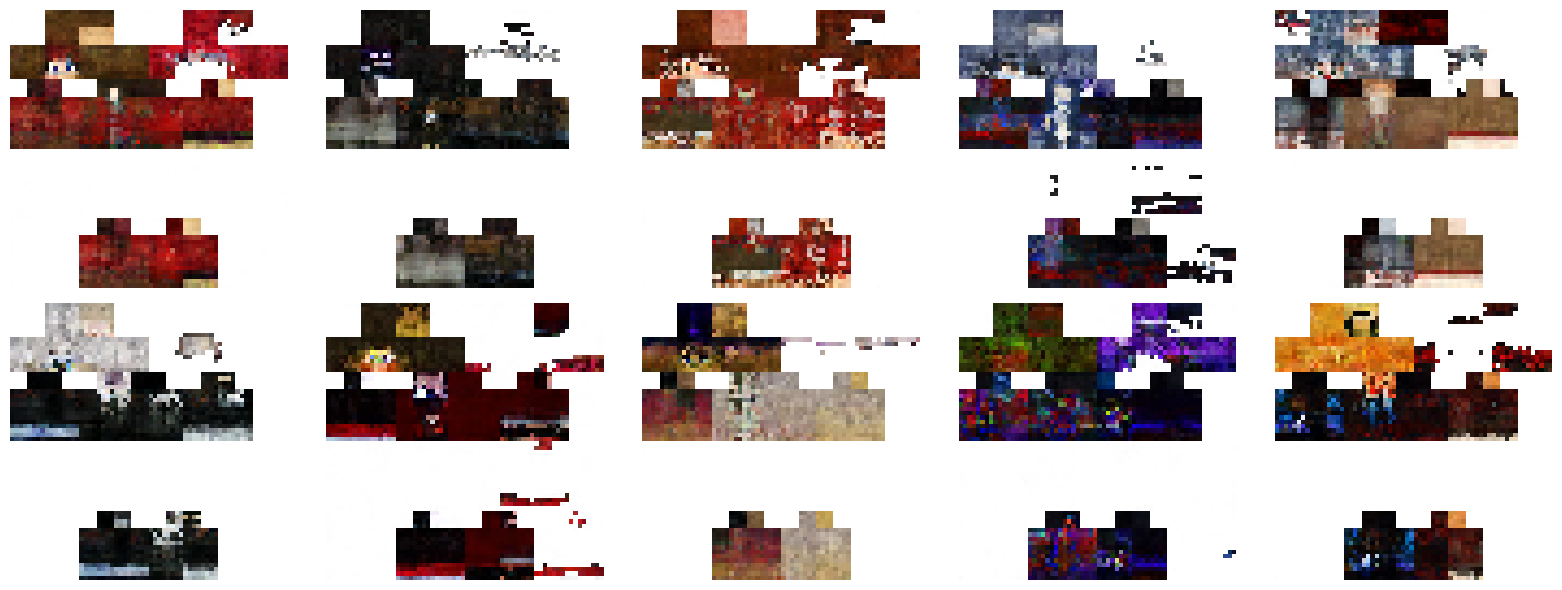

training examples:35000, loss:0.013694674707949162


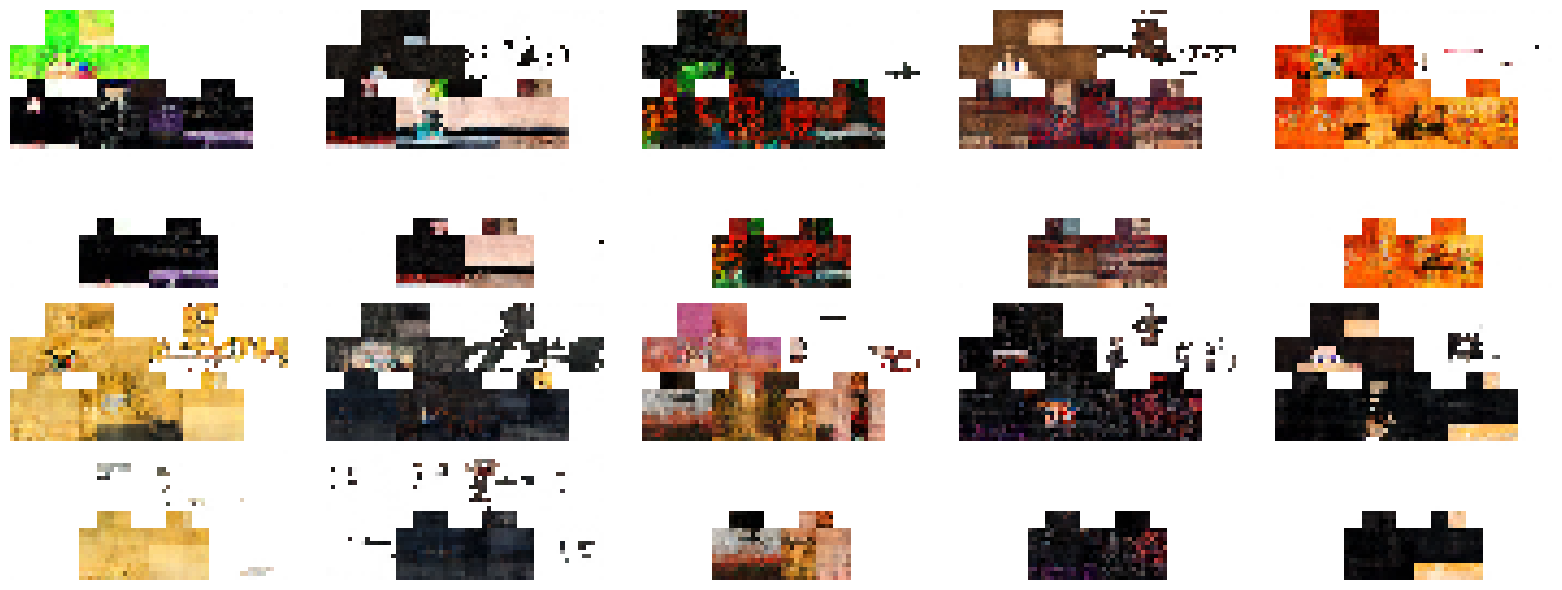

training examples:70000, loss:0.02874673902988434


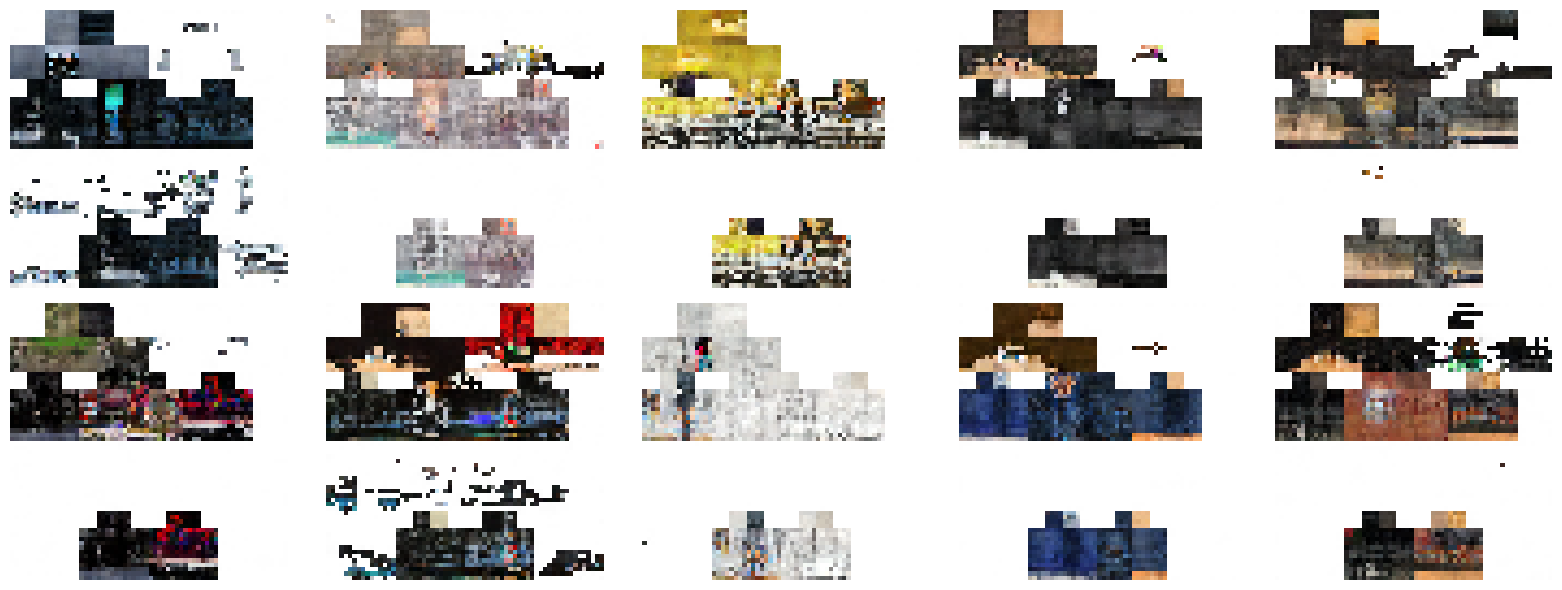

training examples:105000, loss:0.012404355220496655


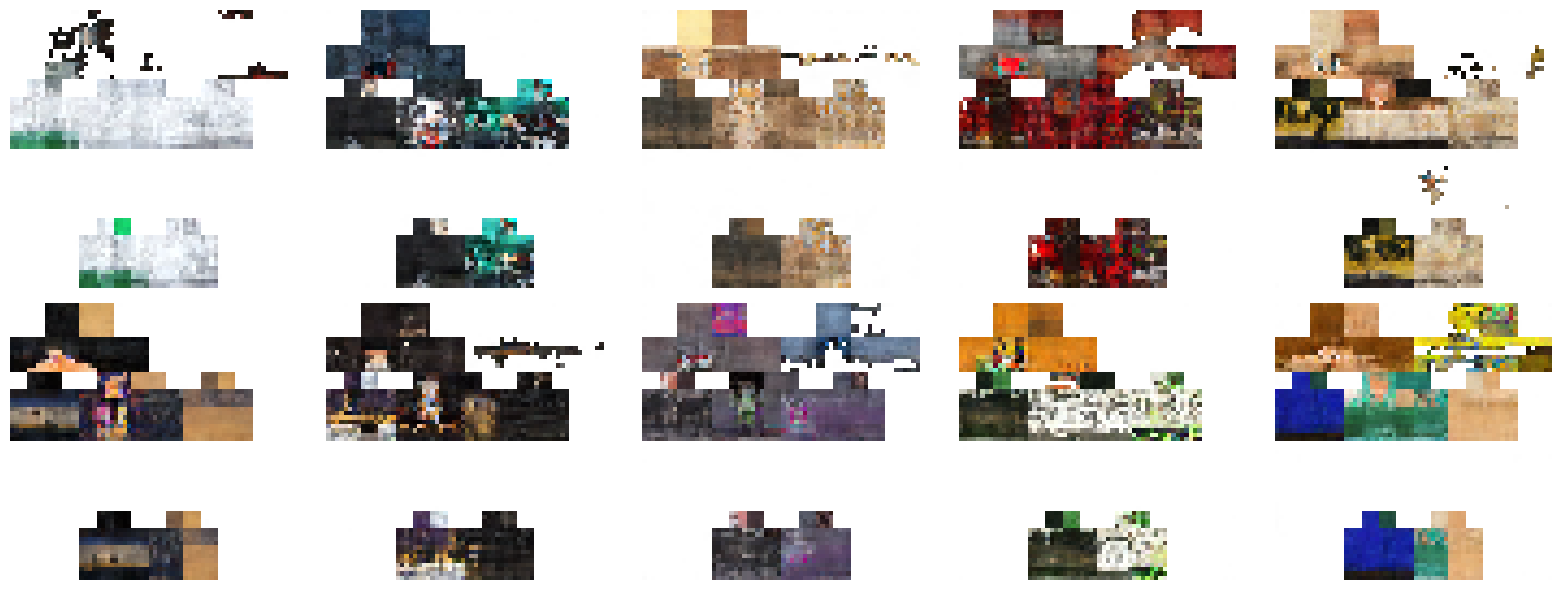

In [98]:
""" Making a custom training loop cuz
train_step doesn't have the right
args for a simple model.fit()"""
#loss = []

cur_epoch = 5
for epoch in range(cur_epoch, cur_epoch + num_epochs):
    for i,batch in enumerate(dataset):
        l = train_step(batch, model, du, batchsize)
        loss.append(l)
        
        
        if i % 5000==0:
            manager.save()
            print(f'training examples:{i * batchsize}, loss:{l}')
            plot_image(sample(model, du), f'{epoch}-{i*batchsize}')

            
        if i >= 15000:
            break

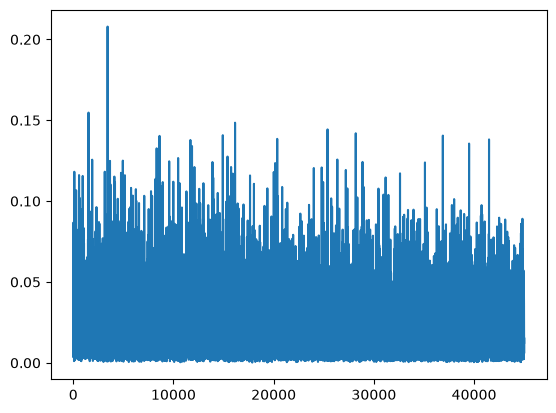

In [99]:
plt.plot(loss)
plt.show()

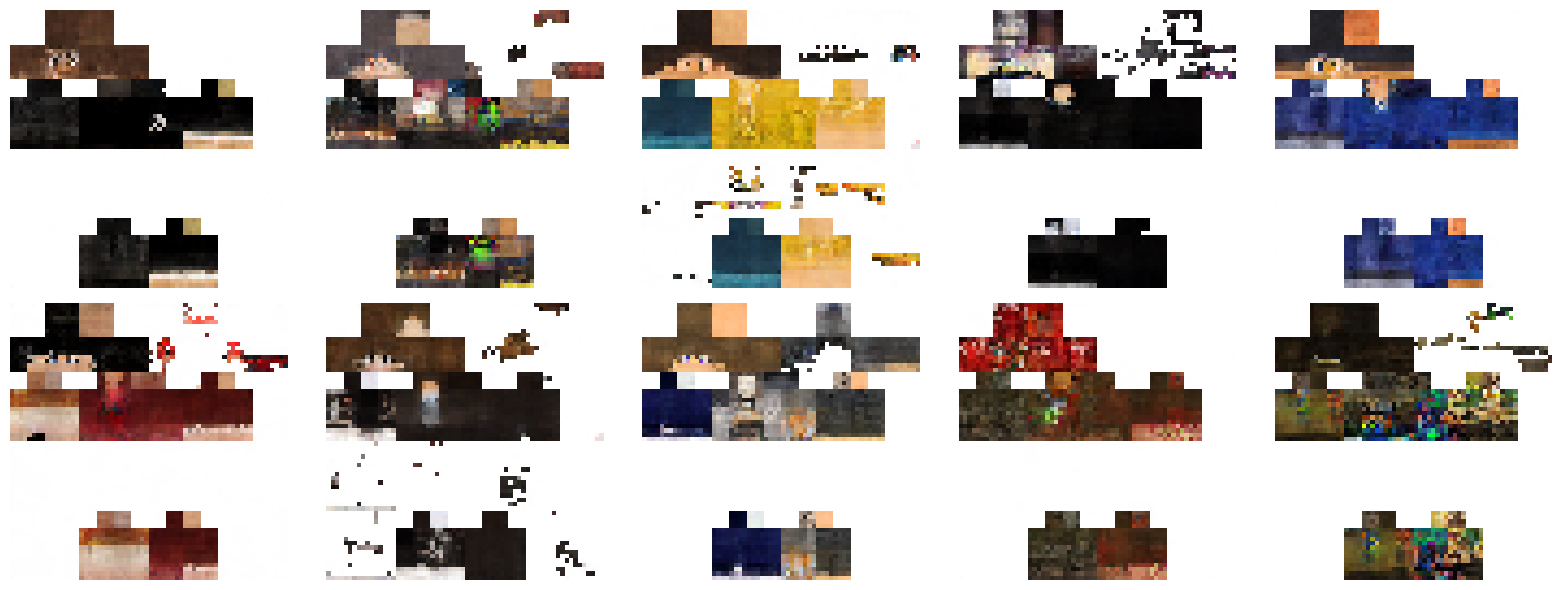

In [100]:
plot_image(sample(model, du), f'{epoch}-{i/5000}')